### Import data

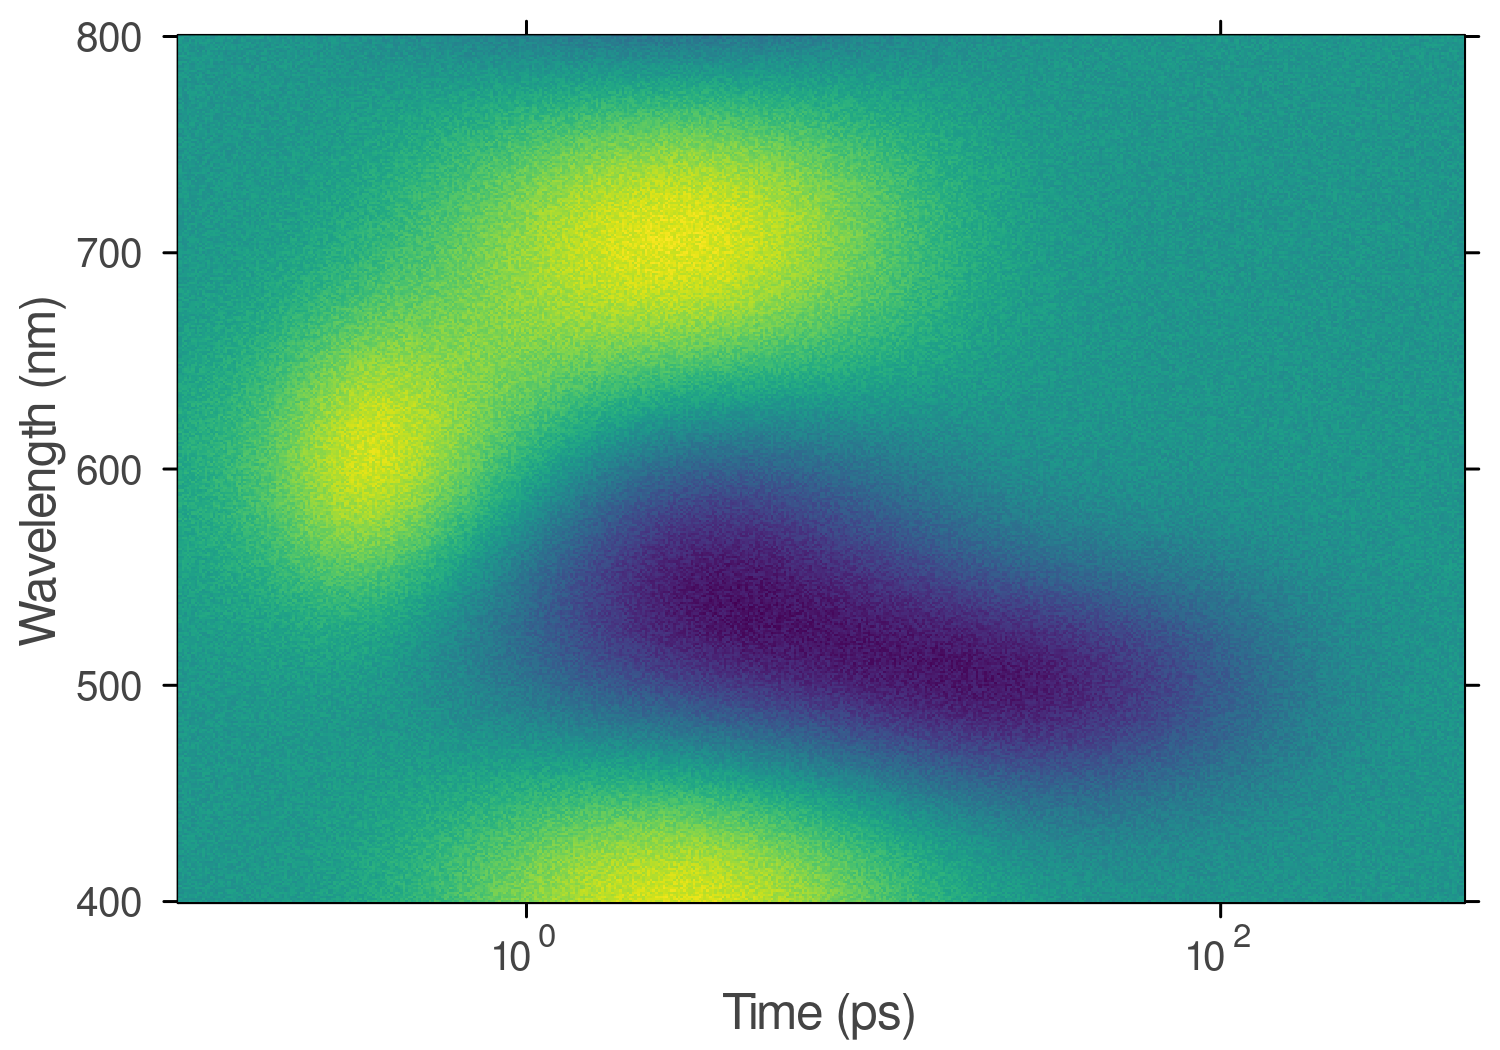

In [17]:
using Metaheuristics

include("../src/import.jl")
include("../src/plots.jl")

# define .csv file containing experimental data
# file = raw"C:\Data\testdat_first_order_seq.csv"
file = joinpath("..", "data", "testData_first_order_seq.csv")

# import data
data = importData(file)[1]
# spectral dimension
s = data.x
# time dimension
t = data.y
# 2D data
d = data.z

# plot dataset for quick overview
tBl = t .> 0
heatmap(t[tBl], s, d[:,tBl], xscale=:log10, c=:viridis,
    xlabel="Time (ps)", ylabel="Wavelength (nm)")

### Define kinetic model

In [18]:
include("../src/kinetic.jl")

# define kinetic model
rn = @reaction_network begin
    k1, A --> B
    k2, B --> C
    k3, C --> 0
end

# define starting values and bounds for the parameter optimization 
limits = Dict(
    :A => 1,
    :B => 0,
    :C => 0,
    :k1 => [5e-1, 5],
    :k2 => [5e-2, 5e-1],
    :k3 => [5e-3, 5e-2],
    :μ => [-0.5, 0.5],
    :σ => [0.04, 0.2]
)

# show reaction network
using Latexify
latexify(rn)

L"\begin{align*}
\mathrm{A} &\xrightarrow{\mathtt{k1}} \mathrm{B} \\
\mathrm{B} &\xrightarrow{\mathtt{k2}} \mathrm{C} \\
\mathrm{C} &\xrightarrow{\mathtt{k3}} \varnothing  
 \end{align*}
"

### Run the optimization

In [19]:
# maximum number of iterations
maxIter = 100

# preprocess reaction network
syms, bounds, odeHelpers = setupVariables(rn, limits)

# run optimization
options = Options(iterations=maxIter, parallel_evaluation=true, store_convergence=true)
result = Metaheuristics.optimize((param)->paramToSSRParallel(t, param, d, odeHelpers),
    bounds, DE(N=10;options))

Optimization Result
===================
  Iteration:       100
  Minimum:         590.246
  Minimizer:       [1.00028, 0.10046, 0.0100223, …, 0.0997996]
  Function calls:  1000
  Total time:      34.3540 s
  Stop reason:     Maximum number of iterations exceeded.

### Monitor fit convergence
You can increase `maxIter` if there is no clear convergence.

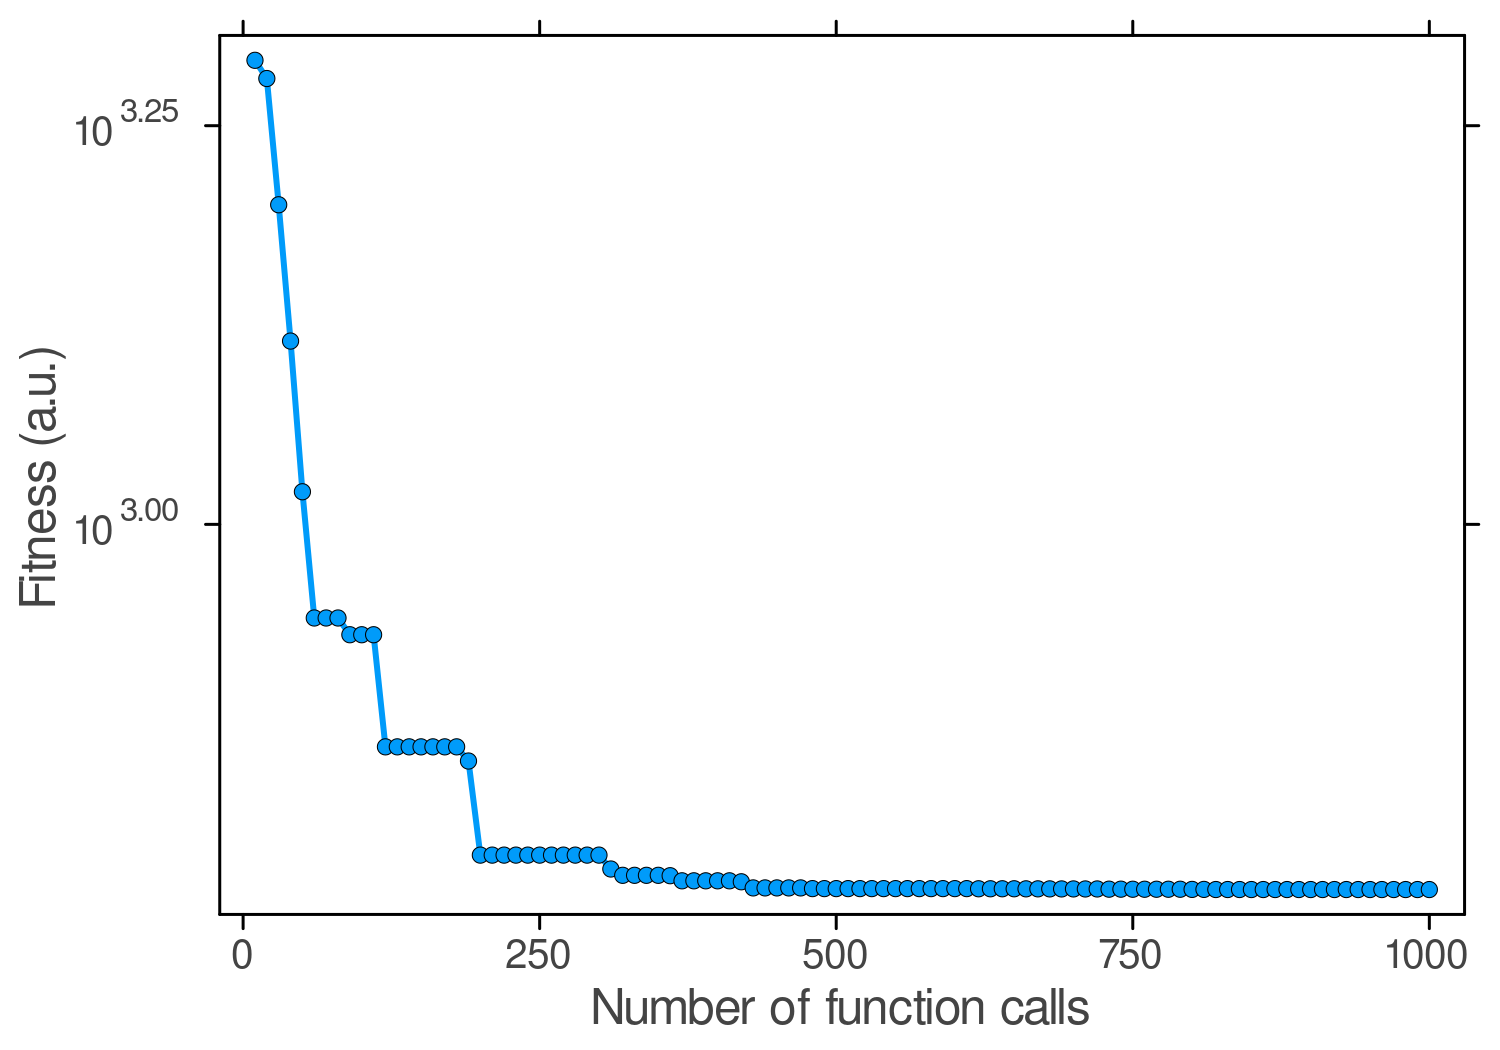

In [20]:
plot(convergence(result)..., xlabel="Number of function calls", ylabel="Fitness (a.u.)",
    marker=:circle, ms=3, msw=0.5, yscale=:log10)

### Get fit parameters
Calculates fit parameters and their confidence intervals.

In [21]:
# confidence level at which to generate the confidence intervals (e.g., 0.95 for 95%)
confidenceLevel = 0.95

# get optimized parameters
fitParam = minimizer(result)

# get confidence intervals on parameters
ci,_ = getParamConfidence(t, fitParam, d, odeHelpers; confidenceLevel=confidenceLevel)

# print mean fit value ± confidence interval
printFitResult(fitParam, ci, syms, odeHelpers[2])

k1: 1.0002816167760311 ± 0.0042763919791576075
k2: 0.10046000405051209 ± 0.0005161326238422253
k3: 0.010022349614674112 ± 4.9376388596912e-5
μ: 0.19984134420983 ± 0.0005094274396330147
σ: 0.09979961002358176 ± 0.0007441254656281801


### Get fit data

Calculates the optimised kinetics and spectra, and propagates parameter uncertainty to the desired confidence level by Monte-Carlo sampling of the parameter covariance matrix.

In [22]:
# number of Monte Carlo samples (100-200 for regular fits, 500-1000 for publication quality)
samples = 100

# get best fit data based on optimized fit parameters
fitData, fitSpc, fitKin = paramToDataCI(t, fitParam, d, odeHelpers; 
    samples=samples, confidenceLevel=confidenceLevel)

# tail probability
pTail = (1 - confidenceLevel)/2 

# confidence intervals for kinetics
ciLowKin  = pquantile.(fitKin, pTail)
ciHighKin = pquantile.(fitKin, 1 - pTail)

# confidence intervals for spectra
ciLowSpc  = pquantile.(fitSpc, pTail)
ciHighSpc = pquantile.(fitSpc, 1 - pTail)

401×3 Matrix{Float64}:
  0.00198003   0.978334  -0.0390882
 -0.00676514   0.996822  -0.0507527
 -0.00663962   0.980191  -0.0451949
 -0.00218548   0.979563  -0.0430728
  0.0160444    0.969189  -0.05818
 -0.00288026   0.974839  -0.0465634
  0.00363692   0.96215   -0.0548074
  1.45573e-5   0.96068   -0.0593332
  0.00986252   0.944409  -0.0606052
 -0.00351      0.96109   -0.0775951
  ⋮                      
 -0.00819096  -0.134098   0.00941508
 -0.0153887   -0.149373  -0.00892202
 -0.0196683   -0.16253   -0.00753491
  0.00979129  -0.193794   0.014953
  0.0126956   -0.228609   0.0131634
  0.0014196   -0.233716  -0.00947857
  0.0120167   -0.251386   0.0057787
  0.0100179   -0.274311  -0.00309096
 -0.00475899  -0.290322  -0.00408233

### Plot optimized kinetics

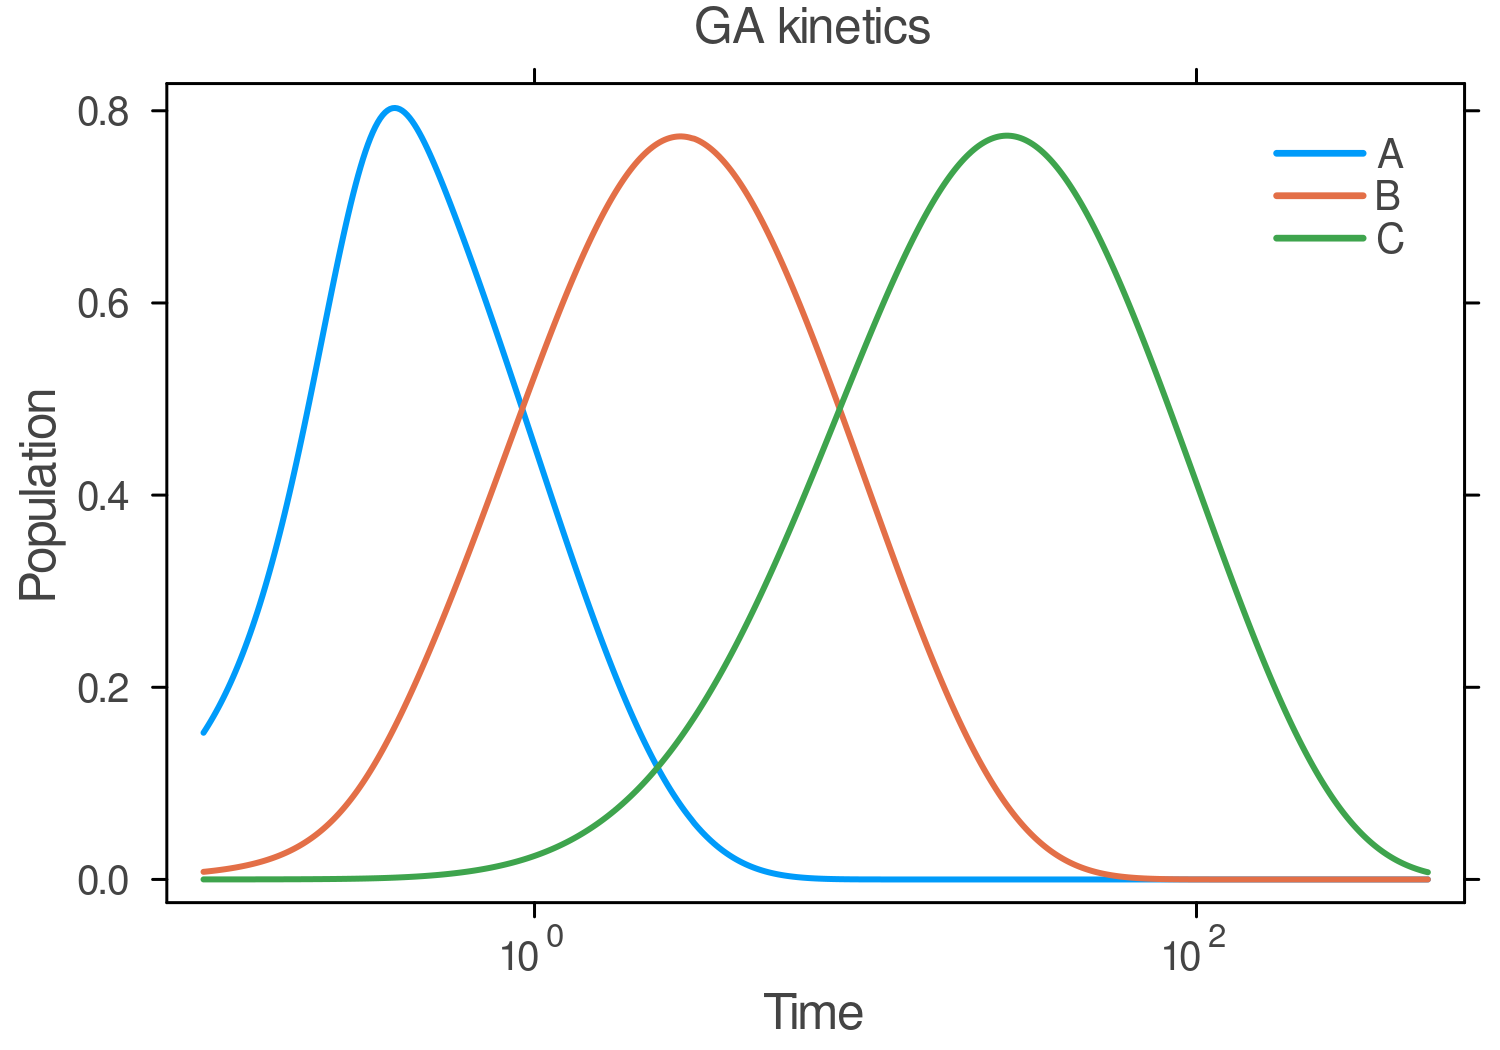

In [23]:
# positive times for log plot
tBl = t .> 0

# center values
cent = pmean.(fitKin[tBl,:])
# lower confidence level
lower = cent .- ciLowKin[tBl,:]
# upper confidence level
upper = ciHighKin[tBl,:] .- cent

plot(t[tBl], cent, ribbon=(lower,upper), xscale=:log10, 
    title="GA kinetics", xlabel="Time", ylabel="Population", 
    legend=true, label=getLabels(rn))

### Plot optimized spectral signatures

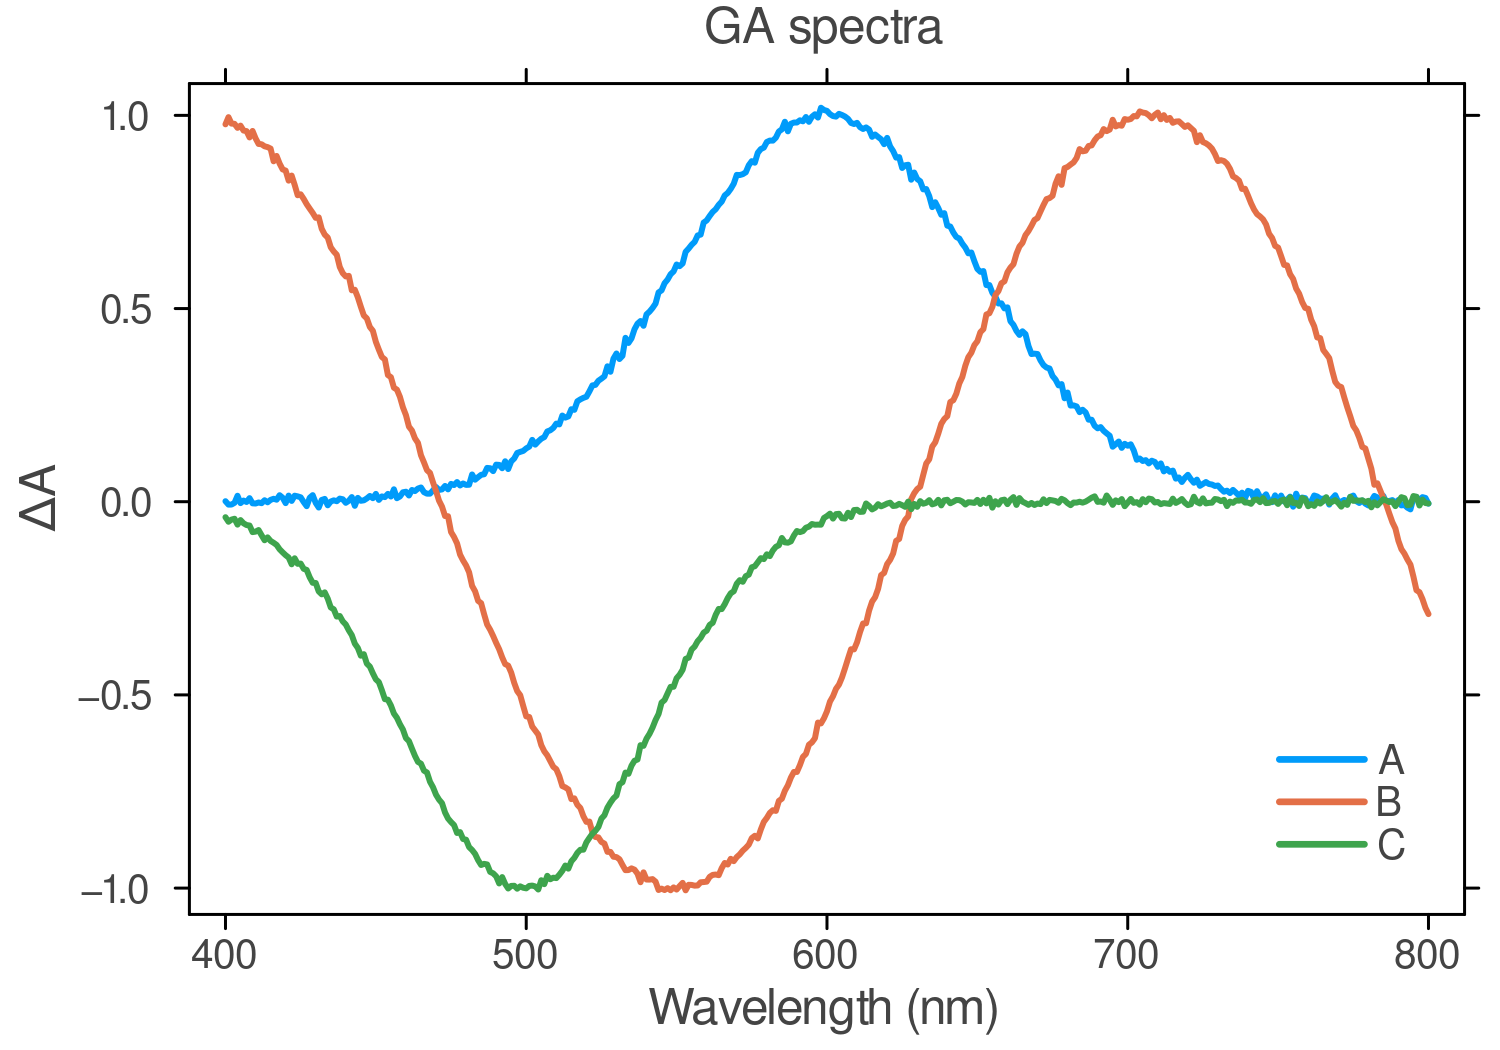

In [24]:
# center values
cent = pmean.(fitSpc)
# lower confidence level
lower = cent .- ciLowSpc
# upper confidence level
upper = ciHighSpc .- cent

plot(s, cent, ribbon=(lower,upper),title="GA spectra", 
    xlabel="Wavelength (nm)", ylabel="ΔA", 
    legend=true, label=getLabels(rn))

### Plot fit residuals

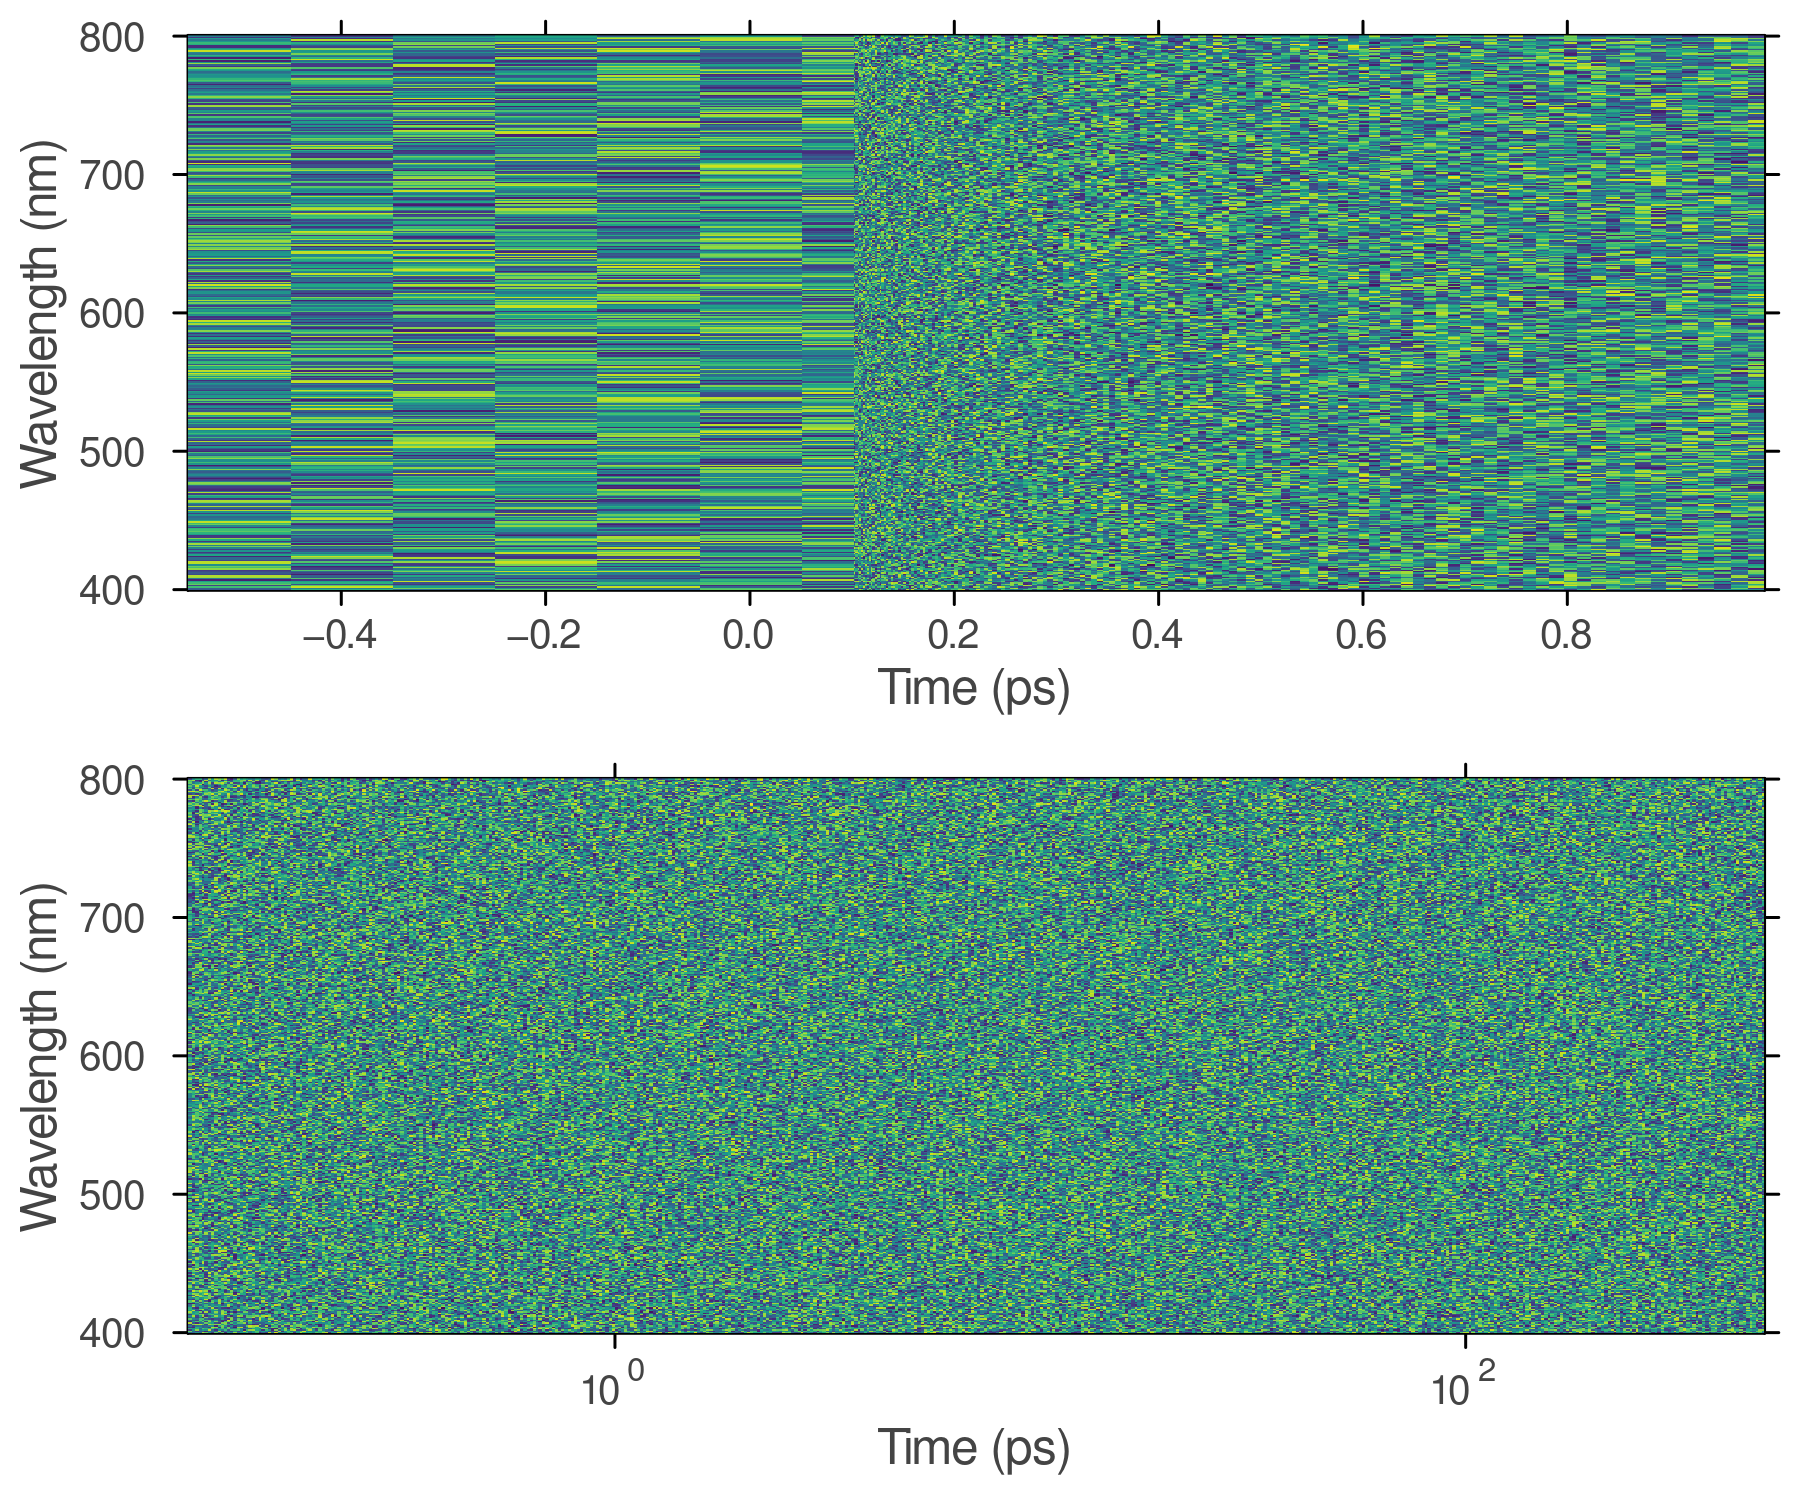

In [25]:
# convert to center values
fitData = pmean.(fitData)

# linear plot around t = 0
tBl = -0.5 .≤ t .≤ 1
p1 = heatmap(t[tBl], s, d[:,tBl] .- fitData[:,tBl], c=:viridis,
    xlabel="Time (ps)", ylabel="Wavelength (nm)")

# log plot at positive times
tBl = t .> 0
p2 = heatmap(t[tBl], s, d[:,tBl] .- fitData[:,tBl], c=:viridis,
    xscale=:log10, xlabel="Time (ps)", ylabel="Wavelength (nm)")

# combine plots
plot(p1,p2, layout=(2,1), size=(600,500))

# Calculate fit statistics

Used to judge goodness-of-fit and help with model-selection.

In [26]:
include("../src/fits.jl")

# convert to center values
fitData = pmean.(fitData)

# number of fit variables (excluding fixed variables)
numFitVar = getNumFitVar(limits)

# calculate adjusted R²
adjR2 = calculateAdjR2(d, fitData, numFitVar)

println("Adjusted R-square: $(adjR2)")

# get baseline noise estimate from region of data with no transient
# signal (here we use pre-t0 data; adjust if your t0 is offset)
tBl = t .< 0
σ = nanstd(d[:,tBl],dim=2)
σs = repeat(σ, 1, length(t)) 

# calculate χ² and reduced χ²
chiSq, redChiSq = calculateChiSq(d, fitData, numFitVar, σ=σs)

println("Chi-square: $(chiSq)")
println("Reduced chi-square: $(redChiSq)")

# calculate corrected Akaike Information Criterion
AICc = calculateAICc(d, fitData, numFitVar)

println("Corrected Akaike Information Criterion: $(AICc)")

# calculate Bayesian Information Criterion
BIC = calculateBIC(d, fitData, numFitVar)

println("Bayesian Information Criterion: $(BIC)")


Adjusted R-square: 0.975335892567504
Chi-square: 241440.94119465732
Reduced chi-square: 1.0018462596667883
Corrected Akaike Information Criterion: -1.448891649227317e6
Bayesian Information Criterion: -1.4488396866944756e6
